In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# **Environment Setup**

In [4]:
#loaded the data both are the different files here train and test so thats why two different variables 
#because of two different files
train = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

In [5]:
#now its time to get the train and test data ready label column is target coulmn has values 0-9
#i will drop the label for train and test for X
X = train.drop('label', axis=1).values
y = train['label'].values

In [6]:
X_test = test.drop('label', axis=1).values
y_test = test['label'].values

In [7]:
#now i will normalize the values for this i recalled my ds concept to use minmax scalar
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

#here i tried to use minmax scalar but by which i was getting a value of 1.3 in test.max() 
#but the assignment requirement was 0-1 so i divided it with max number 255

X = X / 255.0
X_test = X_test / 255.0

print("Training shape:", X.shape)
print("Test shape:", X_test.shape)
print("Training min:", X.min())
print("Training max:", X.max())
print("Test min:", X_test.min())
print("Test max:", X_test.max())

Training shape: (60000, 784)
Test shape: (10000, 784)
Training min: 0.0
Training max: 1.0
Test min: 0.0
Test max: 1.0


In [8]:
#data has already 784 columns so it is falattend already
print("X shape:", X.shape)
print("Test shape:", X_test.shape)

X shape: (60000, 784)
Test shape: (10000, 784)


In [9]:
#train test validation splitting 
#number of sample in each split
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [10]:
#class distritbution 0-9
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training class distribution:
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64

Test class distribution:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


# PART 1

In [11]:
# ReLU function for hidden layers
def relu(x):
    return np.maximum(0, x)

# Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

# Softmax for activation
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# one-hot encoding
def one_hot(y, classes):
    result = np.zeros((y.size, classes))
    result[np.arange(y.size), y] = 1
    return result

# Categorial Cross Entropy Loss Fucntion
def calculate_loss(y, output):
    m = y.shape[0]
    return -np.sum(y * np.log(output + 1e-15)) / m

In [12]:
np.random.seed(42)

#weights and bias
W1 = np.random.randn(784,64) * 0.01
b1 = np.zeros((1, 64))
W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1,10))


#i have to copy for torch
W1_initial = W1.copy()
b1_initial = b1.copy()
W2_initial = W2.copy()
b2_initial = b2.copy()

In [13]:
#Taking only 5000 training samples
X = X_train[0:5000]
y = y_train[0:5000]

#for pytorch need a copy
X_batch = X
y_batch = y

#one-hot encoding for categoeries
y_one_hot = one_hot(y, 10)


#here we will see the results of epochs after 5 iterations
epochs = 20
learning_rate = 0.1
losses = []
for epoch in range(epochs):
    #forward
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    loss = calculate_loss(y_one_hot, A2)
    losses.append(loss)

    # Backpropagation
    m = X.shape[0]
    dZ2 = (A2 - y_one_hot) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    #Update
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    if (epoch + 1) % 5 == 0:
        print("Epoch:", epoch + 1, "Loss:", loss)

Epoch: 5 Loss: 2.2980597178845135
Epoch: 10 Loss: 2.2863589031136797
Epoch: 15 Loss: 2.262202776536237
Epoch: 20 Loss: 2.2150265810148526


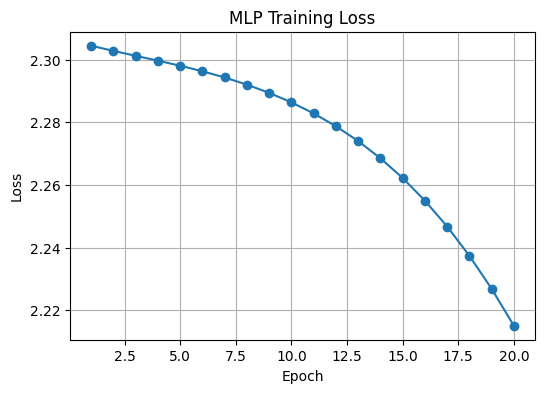

In [14]:
# Plot the loss
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [15]:
#pytorch
model = nn.Sequential(nn.Linear(784, 64),nn.ReLU(),
    nn.Linear(64, 10))

#the copies i created in upper cell will be used here 
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_initial.T))
    model[0].bias.copy_(torch.tensor(b1_initial.flatten()))

    model[2].weight.copy_(torch.tensor(W2_initial.T))
    model[2].bias.copy_(torch.tensor(b2_initial.flatten()))

In [16]:
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

#Forward
output = model(X_torch)

#loss
loss = nn.CrossEntropyLoss()(output, y_torch)

#Backward
loss.backward()

In [17]:
#pytorch gradiet
dW1_torch = model[0].weight.grad.numpy().T
dW2_torch = model[2].weight.grad.numpy().T

In [18]:
#absolute differ
difference_W1 = np.max(np.abs(dW1 - dW1_torch))
difference_W2 = np.max(np.abs(dW2 - dW2_torch))

print("Maximum difference for W1:", difference_W1)
print("Maximum difference for W2:", difference_W2)


Maximum difference for W1: 0.006655703195778628
Maximum difference for W2: 0.030647577130394975


In [19]:
np.random.seed(42)
tf.random.set_seed(42)

#encoding
y_train_cat = to_categorical(y_train, 10)
y_val_cat = to_categorical(y_val, 10)

In [22]:
X_grad_sample = X_val[0:128]
y_grad_sample = y_val_cat[0:128]

In [24]:
#this will get the gradient i get the issue and get to know
#fit() doesnt give me graident so this will get it
class GradientLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_sample, y_sample):
        super().__init__()
        self.X_sample = X_sample
        self.y_sample = y_sample
        self.grad_history = []

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            preds = self.model(self.X_sample, training=True)
            loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(self.y_sample, preds))

        first_layer_w = self.model.layers[0].trainable_weights[0]
        grad = tape.gradient(loss, [first_layer_w])[0]
        self.grad_history.append(tf.reduce_mean(tf.abs(grad)).numpy())

In [25]:
#Sigmoid
sigmoid_model = Sequential([
    Dense(128, input_dim=784, activation='sigmoid'),
    Dense(64, activation='sigmoid'),
    Dense(10, activation='softmax')
])

sigmoid_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

sigmoid_logger = GradientLogger(X_grad_sample, y_grad_sample)

sigmoid_history = sigmoid_model.fit(X_train, y_train_cat,
                                     validation_data=(X_val, y_val_cat),
                                     epochs=5, batch_size=128,
                                     callbacks=[sigmoid_logger],
                                     verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7080 - loss: 0.9919 - val_accuracy: 0.8103 - val_loss: 0.5653
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8289 - loss: 0.4946 - val_accuracy: 0.8357 - val_loss: 0.4530
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8488 - loss: 0.4246 - val_accuracy: 0.8497 - val_loss: 0.4133
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8615 - loss: 0.3898 - val_accuracy: 0.8592 - val_loss: 0.3910
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8696 - loss: 0.3667 - val_accuracy: 0.8631 - val_loss: 0.3763


In [26]:
#TANH
tanh_model = Sequential([
    Dense(128, input_dim=784, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(10, activation='softmax')
])

tanh_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

tanh_logger = GradientLogger(X_grad_sample, y_grad_sample)

tanh_history = tanh_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[tanh_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8066 - loss: 0.5567 - val_accuracy: 0.8135 - val_loss: 0.4855
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8580 - loss: 0.3945 - val_accuracy: 0.8367 - val_loss: 0.4249
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8727 - loss: 0.3566 - val_accuracy: 0.8457 - val_loss: 0.4032
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8809 - loss: 0.3315 - val_accuracy: 0.8505 - val_loss: 0.3916
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8878 - loss: 0.3115 - val_accuracy: 0.8537 - val_loss: 0.3834


In [27]:
#RELU 
relu_model = Sequential([
    Dense(128, input_dim=784, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

relu_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

relu_logger = GradientLogger(X_grad_sample, y_grad_sample)

relu_history = relu_model.fit(X_train, y_train_cat,
                               validation_data=(X_val, y_val_cat),
                               epochs=5, batch_size=128,
                               callbacks=[relu_logger],
                               verbose=1)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8023 - loss: 0.5744 - val_accuracy: 0.8382 - val_loss: 0.4443
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8562 - loss: 0.4060 - val_accuracy: 0.8373 - val_loss: 0.4370
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8696 - loss: 0.3654 - val_accuracy: 0.8341 - val_loss: 0.4338
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8791 - loss: 0.3373 - val_accuracy: 0.8451 - val_loss: 0.4117
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8861 - loss: 0.3175 - val_accuracy: 0.8483 - val_loss: 0.4034


In [28]:
#LEAKY RELU 
leaky_model = Sequential([
    Dense(128, input_dim=784),
    LeakyReLU(alpha=0.01),
    Dense(64),
    LeakyReLU(alpha=0.01),
    Dense(10, activation='softmax')
])

leaky_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

leaky_logger = GradientLogger(X_grad_sample, y_grad_sample)

leaky_history = leaky_model.fit(X_train, y_train_cat,
                                 validation_data=(X_val, y_val_cat),
                                 epochs=5, batch_size=128,
                                 callbacks=[leaky_logger],
                                 verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8010 - loss: 0.5861 - val_accuracy: 0.8400 - val_loss: 0.4504
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8559 - loss: 0.4119 - val_accuracy: 0.8447 - val_loss: 0.4189
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.3690 - val_accuracy: 0.8394 - val_loss: 0.4228
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8780 - loss: 0.3421 - val_accuracy: 0.8363 - val_loss: 0.4277
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8833 - loss: 0.3237 - val_accuracy: 0.8443 - val_loss: 0.4088


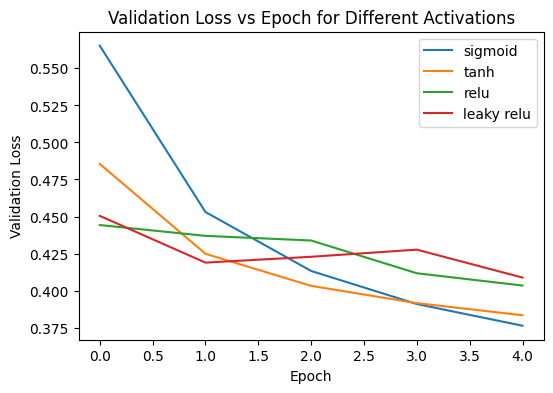

In [36]:
# plotting all 4 val loss curves together
plt.figure(figsize=(6,4))
plt.plot(sigmoid_history.history['val_loss'], label='sigmoid')
plt.plot(tanh_history.history['val_loss'], label='tanh')
plt.plot(relu_history.history['val_loss'], label='relu')
plt.plot(leaky_history.history['val_loss'], label='leaky relu')

plt.title("Validation Loss vs Epoch for Different Activations")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [30]:
#epoch 1 and last
print("sigmoid grad epoch 1:", sigmoid_logger.grad_history[0])
print("sigmoid grad last epoch:", sigmoid_logger.grad_history[-1])

print("relu grad epoch 1:", relu_logger.grad_history[0])
print("relu grad last epoch:", relu_logger.grad_history[-1])

sigmoid grad epoch 1: 0.000251478
sigmoid grad last epoch: 0.00040686625
relu grad epoch 1: 0.0015857188
relu grad last epoch: 0.00245384


so by this we can see that for the sigmoid the learning is very less as compared to the relu as there is difference in both values for sigmoid and relu

so in short words the relu provides a better learning as compared to the sigmoid


In [34]:
#if output is 0 it is dead relu
W1_relu, b1_relu = relu_model.layers[0].get_weights()

Z1 = np.dot(X_val[:256], W1_relu) + b1_relu
A1 = relu(Z1)   #relu from p1

dead_units = np.all(A1 == 0, axis=0) #check all
dead_percentage = np.mean(dead_units) * 100
print("percentage of dead relu units:", dead_percentage, "%")

percentage of dead relu units: 3.90625 %


3.9% are 0 this is very small ratio and i think it is not that concerning but to name it this is the dying relu problem for which solution exists but here the number is small so we will ignore it